In [10]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import seaborn as sns 

In [8]:
df = pd.read_csv('/Users/prajwalsubedi/Desktop/Data science/Data Sets/titanic_toy.csv',usecols=['Age','Fare','Survived'])

In [9]:
df

,Age,Fare,Survived
0,22.0,7.2500,0
1,38.0,71.2833,1
2,26.0,7.9250,1
3,35.0,53.1000,1
4,35.0,8.0500,0
...,...,...,...
886,27.0,13.0000,0
887,19.0,30.0000,1
888,NaN,23.4500,0
889,26.0,NaN,1


# Random Imputation

In [11]:
 df.isnull().mean()

Age         0.198653
Fare        0.050505
Survived    0.000000
dtype: float64

In [13]:
x = df.drop(columns=['Survived'])
y= df['Survived']

In [14]:
x_train, x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [15]:
x_train['Age_imputed']=x_train['Age']
x_test['Age_imputed']=x_test['Age']


In [16]:
x_train

,Age,Fare,Age_imputed
331,45.5,28.5000,45.5
733,23.0,13.0000,23.0
382,32.0,7.9250,32.0
704,26.0,7.8542,26.0
813,6.0,31.2750,6.0
...,...,...,...
106,21.0,7.6500,21.0
270,NaN,31.0000,NaN
860,41.0,NaN,41.0
435,14.0,120.0000,14.0


In [20]:
x_train['Age_imputed'][x_train['Age_imputed'].isnull()]=x_train['Age'].dropna().sample(x_train['Age'].isnull().sum()).values
x_test['Age_imputed'][x_test['Age_imputed'].isnull()]=x_train['Age'].dropna().sample(x_test['Age'].isnull().sum()).values

/var/folders/nl/75k6nf4573d4dnj713sbnl5w0000gn/T/ipykernel_32149/1785810995.py:1: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  x_train['Age_imputed'][x_train['Age_imputed'].isnull()]=x_train['Age'].dropna().sample(x_train['Age'].isnull().su

In [21]:
x_train

,Age,Fare,Age_imputed
331,45.5,28.5000,45.5
733,23.0,13.0000,23.0
382,32.0,7.9250,32.0
704,26.0,7.8542,26.0
813,6.0,31.2750,6.0
...,...,...,...
106,21.0,7.6500,21.0
270,NaN,31.0000,25.0
860,41.0,NaN,41.0
435,14.0,120.0000,14.0


/var/folders/nl/75k6nf4573d4dnj713sbnl5w0000gn/T/ipykernel_32149/2620135429.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x_train['Age'],label='original',hist=False)
/var/folders/nl/75k6nf4573d4dnj713sbnl5w0000gn/T/ipykernel_32149/2620135429.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bb

<Axes: xlabel='Age_imputed', ylabel='Density'>

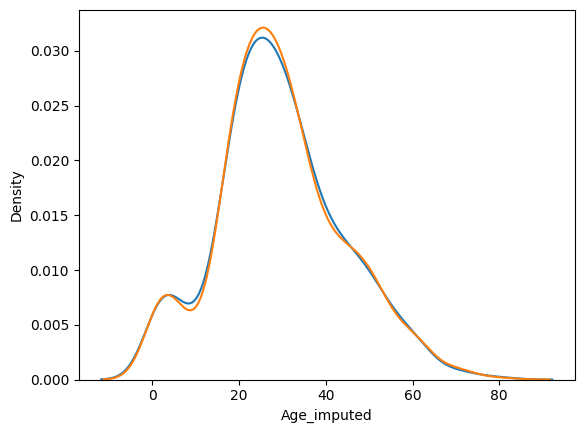

In [22]:
sns.distplot(x_train['Age'],label='original',hist=False)
sns.distplot(x_train['Age_imputed'],label='Imputed',hist=False)

In [23]:
print('Original variable variance',x_train['Age'].var())
print('variance after imputation',x_train['Age_imputed'].var())

Original variable variance 210.2517072477437
variance after imputation 209.28076763993613


In [24]:
x_train[['Fare','Age','Age_imputed']].cov()

,Fare,Age,Age_imputed
Fare,2761.031435,75.481375,65.132775
Age,75.481375,210.251707,210.251707
Age_imputed,65.132775,210.251707,209.280768


<Axes: >

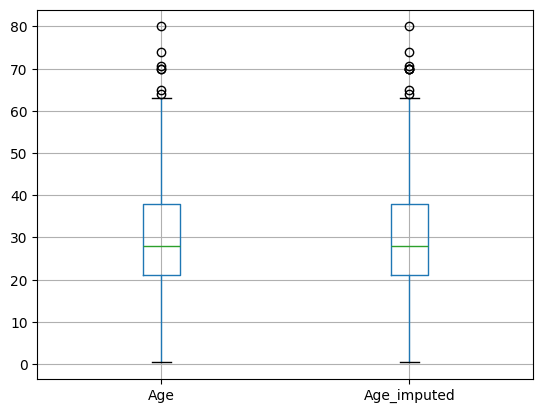

In [25]:
x_train[['Age','Age_imputed']].boxplot()

In [27]:
sampled_value =x_train['Age'].dropna().sample(1,random_state=int(observation['Fare']))

NameError: name 'observation' is not defined

In [31]:

dff =pd.read_csv('/Users/prajwalsubedi/Desktop/Data science/Data Sets/house-train.csv',usecols=['GarageQual','FireplaceQu','SalePrice'])

In [32]:
dff.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   FireplaceQu  770 non-null    object
 1   GarageQual   1379 non-null   object
 2   SalePrice    1460 non-null   int64 
dtypes: int64(1), object(2)
memory usage: 34.3+ KB


In [34]:
dff.isnull().mean()

FireplaceQu    0.472603
GarageQual     0.055479
SalePrice      0.000000
dtype: float64

In [36]:
x = dff
y = dff['SalePrice']

In [37]:
x_train,x_test,y_train,y_test = train_test_split(x,y, train_size=0.2,random_state=42)

In [39]:
x_train['GarageQual_imputed']=x_train['GarageQual']
x_test['GarageQual_imputed']=x_test['GarageQual']

x_train['FireplaceQu_imputed']=x_train['FireplaceQu']
x_test['FireplaceQu_imputed']=x_test['FireplaceQu']

In [40]:
x_train.sample(5)

,FireplaceQu,GarageQual,SalePrice,GarageQual_imputed,FireplaceQu_imputed
1329,TA,TA,176500,TA,TA
563,Gd,TA,185000,TA,Gd
1129,NaN,TA,140000,TA,NaN
524,TA,TA,315750,TA,TA
1380,NaN,TA,58500,TA,NaN
